In [1]:
%load_ext autoreload
%autoreload 2
%autosave 30
%matplotlib inline

Autosaving every 30 seconds


# Comparison and validation of FID implementation
As we used an autoencoder for the FID computation this notebook explores if this method can actually give insighs to the realness of the post-processed forecasts

For this, we will:
- Compute the FID for different post prosessing models
  - and explore relationships to the crps and other error measures
- Use different specification of the autoencoder
  - to explore how the size of the hidden dimension influences results
- Test if the FID increases when non-realistic forecasts are presented
  - for this we can use the averaged forecasts of the ensemble which should be "too smooth"
  - inject some sort of noise to the forecasts

In [2]:
import re
from functools import partial
from itertools import product

import hvplot.polars  # noqa: F401
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import xarray as xr
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset

from genpp import BASE_DIR
from genpp.data.weatherbench2 import (
    FC_VARS,
    FORECAST_ENS_PATH,
    TEST_PREDICTIONS,
    TRAIN_PREDICTIONS,
    VAL_PREDICTIONS,
)
from genpp.eval import best_encoders, best_models
from genpp.eval.FID import fid
from genpp.eval.utils import load_predictions_dataarray

## Load the encoder model

In [3]:
encoder = best_encoders.classifierEncoder.model

/home/feik/GenPP/src/genpp/eval/__init__.py:78: UserWarning: UnpicklingError encountered when loading model zln61d2q: Trying without weights_only.
  warnings.warn(


Ignored args: (), kwargs: {'use_rescaler': False, 'rescaler': None}
Loading channel_means from checkpoint
Loading channel_stds from checkpoint


## Generate the embeddings for the forecasts

In [4]:
predictions = []
_re = re.compile(r"predictions(?:_(?P<variant>.+))?$")

for model_name, models in best_models:
    for model in models:
        print(f"Processing model: {model_name}")
        for file in list(model.model_dir.rglob("val_predictions*.zarr")):
            print(file)
            model_dict = {}
            model_dict["name"] = model_name
            model_dict["tag"] = model.tag
            key = model_name
            if model.tag:
                key += f"_{model.tag}"
            m = _re.search(file.stem)
            suffix = m.group("variant") if m and m.group("variant") else None
            if suffix:
                key += f"_{suffix}"
            model_dict["dependency_model"] = suffix
            model_dict["full_name"] = key
            model_dict["file"] = file

            predictions.append(model_dict)

Processing model: emos
/home/feik/GenPP/outputs/EMOS/2026-02-15_17-09-13/val_predictions_gca.zarr
/home/feik/GenPP/outputs/EMOS/2026-02-15_17-09-13/val_predictions_ecc.zarr
Processing model: drn
/home/feik/GenPP/outputs/DRN/2026-02-06_13-30-02/val_predictions_gca.zarr
/home/feik/GenPP/outputs/DRN/2026-02-06_13-30-02/val_predictions_ecc.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_14-37-36/val_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_15-58-48/val_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_17-48-35/val_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-07_12-15-24/val_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_18-44-54/val_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_19-09-06/val_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_20-38-55/val_predictions.zarr

In [5]:
trainer = L.Trainer(accelerator="auto", logger=False)

for model_dict in predictions:
    val_preds = load_predictions_dataarray(model_dict["file"])
    # Convert to latents
    val_preds_tensor = torch.tensor(val_preds.to_numpy()).float()
    val_preds_tensor = rearrange(
        val_preds_tensor,
        "prediction sample channel height width -> (prediction sample) channel height width",
    )
    dataset = TensorDataset(val_preds_tensor)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)
    latents: list[torch.Tensor] = trainer.predict(encoder, dataloader)  # type: ignore
    latents_cat = torch.cat(latents, dim=0)
    model_dict["latents"] = latents_cat

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


You are using a CUDA device ('NVIDIA RTX A5000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

## Compute the latents for the ground truth dataset
This is the ifs ensemble predictions.

In [6]:
splits = [("train", TRAIN_PREDICTIONS), ("val", VAL_PREDICTIONS), ("test", TEST_PREDICTIONS)]
gt_latents = []
for split, split_prediction in splits:
    gt = (
        xr.open_zarr(FORECAST_ENS_PATH)[FC_VARS]
        .to_dataarray("feature")
        .stack(prediction=("time", "prediction_timedelta"))
        .sel(prediction=split_prediction)
        .transpose("prediction", "number", "feature", "longitude", "latitude")
    )
    gt_tensor = torch.tensor(gt.to_numpy()).float()
    gt_tensor = rearrange(
        gt_tensor,
        "prediction number feature longitude latitude -> (prediction number) feature longitude latitude",
    )
    # Assert no NaNs
    assert not torch.isnan(gt_tensor).any()
    dataset = TensorDataset(gt_tensor)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)
    latents: list[torch.Tensor] = trainer.predict(encoder, dataloader)  # type: ignore
    latents_cat = torch.cat(latents, dim=0)
    gt_latents.append({"split": split, "latents": latents_cat})

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [37]:
rows = []
for gt1, gt2 in product(gt_latents, repeat=2):
    if gt1["split"] > gt2["split"]:
        continue
    elif gt1["split"] == gt2["split"]:
        rows.append(
            {
                "gt_model": gt1["split"],
                "model": gt2["split"],
                "fid": 0.0,
            }
        )
    else:
        fid_value = fid(features1=gt1["latents"], features2=gt2["latents"])
        rows.append(
            {
                "gt_model": gt1["split"],
                "model": gt2["split"],
                "fid": fid_value,
            }
        )
        rows.append(
            {
                "gt_model": gt2["split"],
                "model": gt1["split"],
                "fid": fid_value,
            }
        )
for gt, model in product(gt_latents, predictions):
    try:
        fid_value = fid(features1=model["latents"], features2=gt["latents"])
    except ValueError:
        fid_value = float("nan")
    rows.append(
        {
            "gt_model": gt["split"],
            "model": model["full_name"],
            "fid": fid_value,
        }
    )

# Clip values to be non-negative as these come from numerical errors
fid_df = pl.DataFrame(rows).with_columns(pl.col("fid").clip(0, None))
fid_df

gt_model,model,fid
str,str,f64
"""train""","""train""",0.0
"""train""","""val""",0.0
"""val""","""train""",0.0
"""val""","""val""",0.0
"""test""","""train""",0.0
"""train""","""test""",0.0
"""test""","""val""",0.0
"""val""","""test""",0.0
"""test""","""test""",0.0


## Notes on the following Plot

In the following we will compare the fid scores of the postprocessing models.\
Note that for all postprocessing models, the latents stem from the **validation set**.\
So the bad score for the other sets are somewhat expected.\
However the "real" forecasts should never have a worse score than the post-processed ones. This checks out and is a good sign.


In [38]:
plot_df = (
    fid_df.filter(~pl.col("model").is_in(["train", "val", "test"]))
    .with_columns(
        pl.when(pl.col("model").str.contains("unet") | pl.col("model").str.contains("uvit"))
        .then(
            pl.col("model").str.split("_").list.first()
            + "_"
            + pl.col("model").str.split("_").list.last()
        )
        .otherwise(pl.col("model").str.split("_").list.first().alias("model_type"))
        .str.to_uppercase()
        .alias("model_type"),
        # Method
        pl.when(pl.col("model").str.contains("emos") | pl.col("model").str.contains("drn"))
        .then(pl.col("model").str.split("_").list.last())
        .when(pl.col("model").str.contains("chen") | pl.col("model").str.contains("engression"))
        .then(pl.col("model").str.split("_").list.last())
        .str.to_uppercase()
        .alias("method"),
        # Direct?
        pl.when(pl.col("model").str.contains("dir"))
        .then(pl.lit("Direct"))
        .when(pl.col("model").str.contains("ind"))
        .then(pl.lit("Indirect"))
        .alias("direct"),
    )
    .with_columns(
        pl.when(~pl.col("method").is_null())
        .then(pl.col("model_type") + " (" + pl.col("method") + ")")
        .otherwise(pl.col("model_type"))
        .alias("model_method")
    )
)

In [46]:
print(plot_df)

shape: (72, 7)
┌──────────┬─────────────────────┬───────────┬────────────┬────────┬──────────┬────────────────────┐
│ gt_model ┆ model               ┆ fid       ┆ model_type ┆ method ┆ direct   ┆ model_method       │
│ ---      ┆ ---                 ┆ ---       ┆ ---        ┆ ---    ┆ ---      ┆ ---                │
│ str      ┆ str                 ┆ f64       ┆ str        ┆ str    ┆ str      ┆ str                │
╞══════════╪═════════════════════╪═══════════╪════════════╪════════╪══════════╪════════════════════╡
│ train    ┆ emos_gca            ┆ 13.07012  ┆ EMOS       ┆ GCA    ┆ null     ┆ EMOS (GCA)         │
│ train    ┆ emos_ecc            ┆ 1.108934  ┆ EMOS       ┆ ECC    ┆ null     ┆ EMOS (ECC)         │
│ train    ┆ drn_gca             ┆ 14.566385 ┆ DRN        ┆ GCA    ┆ null     ┆ DRN (GCA)          │
│ train    ┆ drn_ecc             ┆ 0.699002  ┆ DRN        ┆ ECC    ┆ null     ┆ DRN (ECC)          │
│ train    ┆ chen_ind_es         ┆ 62.832603 ┆ CHEN       ┆ ES     ┆ Indirec

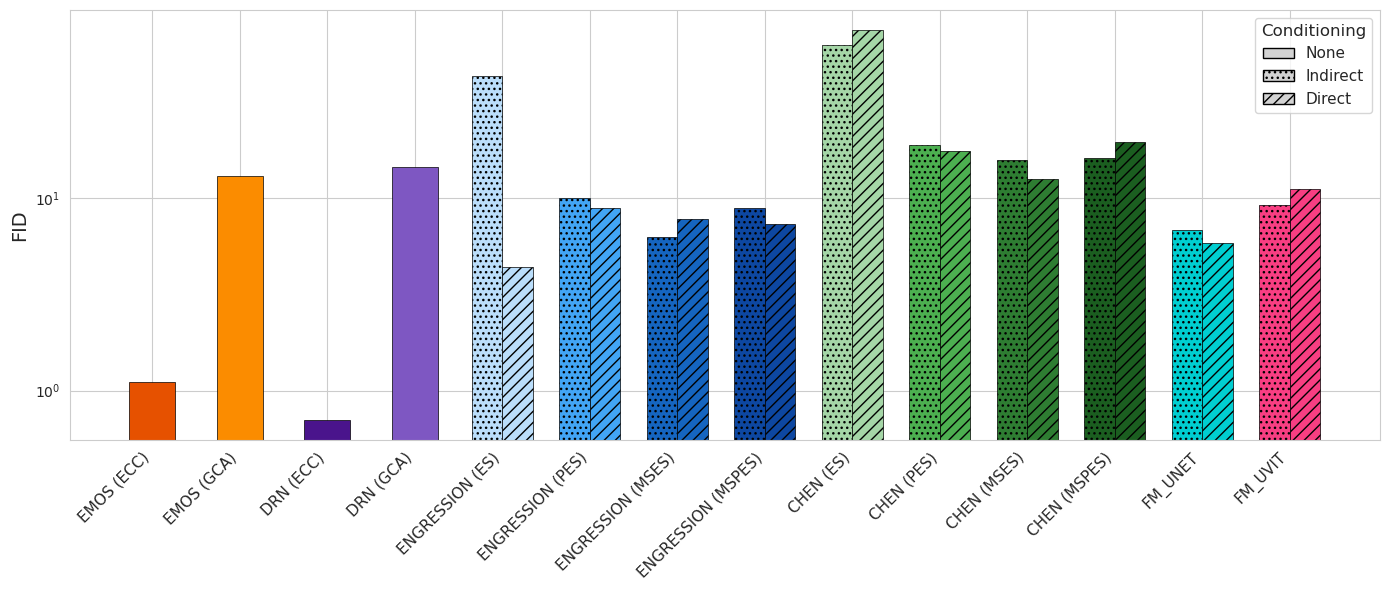

In [ ]:
import seaborn as sns
from matplotlib.patches import Patch

from genpp.plots import RESULTS_DIR

color_mapping = {
    "RAW": "black",
    "EMOS (ECC)": "#E65100",
    "EMOS (GCA)": "#FB8C00",
    "DRN (ECC)": "#4A148C",
    "DRN (GCA)": "#7E57C2",
    "LNGM (ES)": "#A5D6A7",
    "LNGM (PES)": "#4CAF50",
    "LNGM (MSES)": "#2E7D32",
    "LNGM (MSPES)": "#1B5E20",
    "ENGRESSION (ES)": "#BBDEFB",
    "ENGRESSION (PES)": "#42A5F5",
    "ENGRESSION (MSES)": "#1565C0",
    "ENGRESSION (MSPES)": "#0D47A1",
    "FM_UNET": "#00CED1",
    "FM_UVIT": "#F83E82",
    # Also map CHEN variants in case model_method uses CHEN instead of LNGM
    "CHEN (ES)": "#A5D6A7",
    "CHEN (PES)": "#4CAF50",
    "CHEN (MSES)": "#2E7D32",
    "CHEN (MSPES)": "#1B5E20",
}

FULL_HUE_ORDER = [
    "RAW",
    "EMOS (ECC)",
    "EMOS (GCA)",
    "DRN (ECC)",
    "DRN (GCA)",
    "LNGM (ES)",
    "LNGM (PES)",
    "LNGM (MSES)",
    "LNGM (MSPES)",
    "ENGRESSION (ES)",
    "ENGRESSION (PES)",
    "ENGRESSION (MSES)",
    "ENGRESSION (MSPES)",
    "CHEN (ES)",
    "CHEN (PES)",
    "CHEN (MSES)",
    "CHEN (MSPES)",
    "FM_UNET",
    "FM_UVIT",
]
sns.set_style("whitegrid")

# --- Bar plot: FID per model_method, grouped by direct/indirect ---
train_df = plot_df.filter(pl.col("gt_model") == "train")

# Get unique model_methods in the defined order, falling back to data order
present_methods = train_df["model_method"].unique().to_list()
model_methods = [m for m in FULL_HUE_ORDER if m in present_methods]
# Add any that weren't in FULL_HUE_ORDER
model_methods += [m for m in present_methods if m not in model_methods]

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.35
hatch_map = {"Direct": "///", "Indirect": "...", None: ""}

for i, mm in enumerate(model_methods):
    subset = train_df.filter(pl.col("model_method") == mm)
    directs = subset["direct"].to_list()
    color = color_mapping.get(mm, "gray")

    has_variants = any(d is not None for d in directs)

    if not has_variants:
        # Single bar, centered
        val = subset["fid"][0]
        ax.bar(
            i,
            val,
            bar_width * 1.5,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
    else:
        # Two bars: Indirect on left, Direct on right
        for j, d in enumerate(["Indirect", "Direct"]):
            row = subset.filter(pl.col("direct") == d)
            if row.height > 0:
                offset = -bar_width / 2 + j * bar_width
                val = row["fid"][0]
                ax.bar(
                    i + offset,
                    val,
                    bar_width,
                    color=color,
                    hatch=hatch_map[d],
                    edgecolor="black",
                    linewidth=0.5,
                )

ax.set_yscale("log")
ax.set_xticks(range(len(model_methods)))
ax.set_xticklabels(model_methods, rotation=45, ha="right", fontsize=11)
ax.set_ylabel("FID", fontsize=14)
# ax.set_title("FID Scores (Train GT)", fontsize=16)

# Legend for direct/indirect/none hatching
legend_elements = [
    Patch(facecolor="lightgray", edgecolor="black", label="None"),
    Patch(facecolor="lightgray", edgecolor="black", hatch="...", label="Indirect"),
    Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="Direct"),
]
ax.legend(
    handles=legend_elements, title="Conditioning", loc="upper right", fontsize=11, title_fontsize=12
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "results" / "wb2" / "fid_bar_plot.pdf", bbox_inches="tight")

## Lets add some intentionlly "bad" forecasts
For this we use the validation set of real forecasts and apply some transformations such as:
- gaussian noise
- gaussian blur
- black rectangles
- swirl
- salt and pepper noise

This list is taken from the FID paper: [GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium](https://arxiv.org/abs/1706.08500) (Heusel et al., 2018).

But first lets start with the mean forecast

In [ ]:
# Load the data
from torch.utils.data import DataLoader, TensorDataset

from genpp.data.weatherbench2 import FC_VARS

ens_mean = xr.open_dataset(BASE_DIR / "data" / "weatherbench2" / "ens_flat_agg.zarr")
val_slice = slice("2021-01-01", "2021-12-31")

ens_mean = (
    ens_mean.sel(statistic="mean")[FC_VARS]
    .stack(prediction=["time", "prediction_timedelta"])
    .sel(prediction=VAL_PREDICTIONS)
    .to_dataarray("feature")
    .transpose("prediction", "feature", "longitude", "latitude")
)
mean_fc_tensor = torch.tensor(ens_mean.values).float()
mean_fc_dataset = TensorDataset(mean_fc_tensor)
mean_fc_dataloader = DataLoader(mean_fc_dataset, batch_size=128, shuffle=False)

trainer = L.Trainer(logger=False)
ens_mean_preds = trainer.predict(encoder, mean_fc_dataloader)
ens_mean_preds = torch.cat(ens_mean_preds, dim=0)  # type: ignore

predictions.append(
    {
        "name": "ens_mean",
        "tag": None,
        "dependency_model": None,
        "full_name": "ens_mean",
        "file": None,
        "latents": ens_mean_preds,
    }
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
for gt in gt_latents:
    fid_value = fid(
        features1=gt["latents"],
        features2=ens_mean_preds,  # type: ignore
    )
    rows.append(
        {
            "gt_model": gt["split"],
            "model": "ens_mean",
            "fid": fid_value,
        }
    )
# Clip values to be non-negative as these come from numerical errors
fid_df = pl.DataFrame(rows).with_columns(pl.col("fid").clip(0, None))
fid_df

In [ ]:
fid_df.hvplot.heatmap(  # pyright: ignore[reportAttributeAccessIssue]
    x="gt_model",
    y="model",
    C="fid",
    cmap="Reds",
    title="FID Scores Between Models",
    width=800,
    height=600,
    colorbar=True,
)

### Few notes on this

If the Autoencoder is good at encoding forecasts it is probably also good at encoding smoothed forecasts.\
Instead of using an autoencoder use some classifier that can differentiate between forecasts and too smooth forecasts (i.e. mean forecasts)


### Now add some intentional noise

In [4]:
from torchvision.transforms import v2

from genpp.data.weatherbench2.zarr_dataset import TransformTensorDataset

In [5]:
ens_fc = (
    xr.open_dataset(BASE_DIR / "data" / "weatherbench2" / "ifs_ens.zarr")[FC_VARS]
    .stack(prediction=["time", "prediction_timedelta"])
    .sel(prediction=VAL_PREDICTIONS)
    .to_dataarray("feature")
    .transpose("prediction", "number", "feature", "longitude", "latitude")
)

In [ ]:
gaussian_noise = v2.GaussianNoise(mean=0.0, sigma=1, clip=False)  # p=1 by default
gaussian_blur = v2.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))  # p=1 by default
black_rectangle = v2.RandomErasing(
    p=1,
    scale=(0.02, 0.33),
    ratio=(0.3, 3.3),
    value=tuple(ens_fc.mean(["prediction", "number", "longitude", "latitude"]).values),  # type: ignore
)

defects = [gaussian_noise, gaussian_blur, black_rectangle]
for defect in defects:
    name = "ifs_ens+" + defect.__class__.__name__
    ens_fc_tensor = rearrange(
        torch.tensor(ens_fc.values).float(),
        "prediction number feature longitude latitude -> (prediction number) feature longitude latitude",
    )
    ens_fc_ds = TransformTensorDataset(ens_fc_tensor, transform=defect)
    dl = DataLoader(ens_fc_ds, batch_size=265, shuffle=False)
    ens_noised_preds = trainer.predict(encoder, dl)
    ens_noised_preds = torch.cat(ens_noised_preds, dim=0)  # type: ignore

    predictions.append(
        {
            "name": "ifs_ens",
            "tag": defect.__class__.__name__,
            "dependency_model": None,
            "full_name": name,
            "file": None,
            "latents": ens_noised_preds,
        }
    )

    for gt in gt_latents:
        fid_value = fid(
            features1=gt["latents"],
            features2=ens_noised_preds,  # type: ignore
        )
        rows.append(
            {
                "gt_model": gt["split"],
                "model": name,
                "fid": fid_value,
            }
        )

fid_df = pl.DataFrame(rows).with_columns(pl.col("fid").clip(0, None))
fid_df

In [ ]:
fid_df.hvplot.heatmap(  # pyright: ignore[reportAttributeAccessIssue]
    x="gt_model",
    y="model",
    C="fid",
    cmap="Reds",
    title="FID Scores Between Models",
    width=800,
    height=600,
    colorbar=True,
)

## Compute the scores in latent space

In [ ]:
from genpp.data.weatherbench2 import OBSERVATIONS_FLAT_PATH
from genpp.models.scores import EnergyScore, EnsembleCRPS

In [ ]:
# get the embeddings for the reforecast dataset
y_val = (
    xr.open_dataset(OBSERVATIONS_FLAT_PATH)
    .sel(
        time=VAL_PREDICTIONS.get_level_values("time")
        + VAL_PREDICTIONS.get_level_values("prediction_timedelta")
    )
    .to_dataarray("feature")
    .sel(feature=FC_VARS)
    .transpose("time", "feature", "longitude", "latitude")
    .rename({"time": "prediction_time"})
    .assign_coords(
        prediction=("prediction_time", VAL_PREDICTIONS),
    )
    .swap_dims({"prediction_time": "prediction"})
)

# pass through the encoder
y_tensor = torch.tensor(y_val.to_numpy()).float()
# Assert no NaNs
assert not torch.isnan(y_tensor).any()
dataset = TensorDataset(y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)
latents: list[torch.Tensor] = trainer.predict(encoder, dataloader)  # type: ignore
y_latents = torch.cat(latents, dim=0)

In [ ]:
scores = []
scores_t = []
scores_per_leadtime = []
CRPS = EnsembleCRPS(n_axis=-2)
ES = EnergyScore(clamp=False)

prediction_timedeltas = VAL_PREDICTIONS.get_level_values("prediction_timedelta").to_numpy()
td = np.unique(prediction_timedeltas)
td_h = [td / np.timedelta64(1, "h") for td in td]

for model in predictions:
    # the CRPS expexts input dim [b, n, d] for x and [b, d] for y
    if model["full_name"] == "ens_mean":
        continue
    latent_reshaped = rearrange(model["latents"], "(b n) d -> b n d", n=50)
    crps = CRPS(latent_reshaped, y_latents)
    energy_score = ES(
        latent_reshaped.unsqueeze(-1).unsqueeze(-1),
        y_latents.unsqueeze(-1).unsqueeze(-1),
        mode="complete",
    )
    mse = torch.mean((latent_reshaped - rearrange(y_latents, "b d -> b 1 d")) ** 2, dim=-1)
    scores.append(
        {
            "model": model["full_name"],
            "crps": crps.mean(),
            "energy_score": energy_score.mean(),
            "mse": mse.mean(),
        }
    )

    for delta, delta_h in zip(td, td_h):
        mask = prediction_timedeltas == delta
        crps_t = crps[mask].mean()
        energy_score_t = energy_score[mask].mean()
        mse_t = mse[mask].mean()
        scores_t.append(
            {
                "model": model["full_name"],
                "prediction_timedelta": delta_h,
                "crps": crps_t,
                "energy_score": energy_score_t,
                "mse": mse_t,
            }
        )

scores_df = pl.DataFrame(scores)
scores_t_df = pl.DataFrame(scores_t)

In [ ]:
p1 = scores_df.hvplot.bar(  # type: ignore[reportArgumentTypeMismatch]
    x="model",
    y="crps",
    title="CRPS on Val Set",
    width=400,
    height=400,
    rot=45,
)

p2 = scores_df.hvplot.bar(  # type: ignore[reportArgumentTypeMismatch]
    x="model",
    y="energy_score",
    title="Energy Score on Val Set",
    width=400,
    height=400,
    rot=45,
)

p3 = scores_df.hvplot.bar(  # type: ignore[reportArgumentTypeMismatch]
    x="model",
    y="mse",
    title="MSE on Val Set",
    width=400,
    height=400,
    rot=45,
)

(p1 + p2 + p3).cols(3)

In [ ]:
p4 = scores_t_df.hvplot.line(  # type: ignore[reportArgumentTypeMismatch]
    x="prediction_timedelta",
    y="crps",
    by="model",
    title="CRPS on Val Set by Prediction Timedelta",
    width=400,
    height=500,
    legend="bottom",
    legend_cols=2,
)

p5 = scores_t_df.hvplot.line(  # type: ignore[reportArgumentTypeMismatch]
    x="prediction_timedelta",
    y="energy_score",
    by="model",
    title="Energy Score on Val Set by Prediction Timedelta",
    width=400,
    height=500,
    legend="bottom",
    legend_cols=2,
)

p6 = scores_t_df.hvplot.line(  # type: ignore[reportArgumentTypeMismatch]
    x="prediction_timedelta",
    y="mse",
    by="model",
    title="MSE on Val Set by Prediction Timedelta",
    width=400,
    height=500,
    legend="bottom",
    legend_cols=2,
)

(p4 + p5 + p6).cols(3)

## Plot effect of different noise strengths

In [11]:
import torch
from torchvision.transforms import v2
from torchvision.transforms.v2 import functional as F


class UnsharpMask(v2.Transform):
    """Apply unsharp masking to sharpen images.

    Unsharp masking works by:
    1. Creating a blurred version of the image
    2. Subtracting it from the original to get high-frequency details
    3. Adding those details back to the original image with amplification
    4. Rescaling to preserve original min/max range per channel

    Formula: output = image + alpha * (image - blurred_image)
    Then rescaled to match original [min, max] range per channel.

    Args:
        sigma (float): Standard deviation for Gaussian blur.
        alpha (float): Strength of sharpening effect.
    """

    def __init__(self, sigma=1.0, alpha=1.5):
        super().__init__()
        self.sigma = sigma
        self.alpha = alpha

    def _transform(self, inpt):
        """Apply unsharp mask to a single input."""
        # Only process image tensors
        if not isinstance(inpt, torch.Tensor):
            return inpt

        # Ensure we're working with float tensors
        original_dtype = inpt.dtype
        if inpt.dtype != torch.float32:
            inpt = inpt.float()

        # Store original min/max per channel [C, H, W]
        # Compute min/max over spatial dimensions (H, W) for each channel
        original_min = inpt.reshape(inpt.size(0), -1).min(dim=1, keepdim=True)[0]  # [C, 1]
        original_max = inpt.reshape(inpt.size(0), -1).max(dim=1, keepdim=True)[0]  # [C, 1]

        # Reshape for broadcasting: [C, 1, 1]
        original_min = original_min.reshape(-1, 1, 1)
        original_max = original_max.reshape(-1, 1, 1)

        # Apply Gaussian blur
        # Convert sigma to kernel size (rule of thumb: kernel_size ≈ 6*sigma + 1)
        kernel_size = int(6 * self.sigma + 1)
        if kernel_size % 2 == 0:
            kernel_size += 1

        blurred = F.gaussian_blur(
            inpt, kernel_size=[kernel_size, kernel_size], sigma=[self.sigma, self.sigma]
        )

        # Apply unsharp mask formula
        sharpened = inpt + self.alpha * (inpt - blurred)

        # Rescale to original range per channel
        sharpened_min = (
            sharpened.reshape(sharpened.size(0), -1).min(dim=1, keepdim=True)[0].reshape(-1, 1, 1)
        )
        sharpened_max = (
            sharpened.reshape(sharpened.size(0), -1).max(dim=1, keepdim=True)[0].reshape(-1, 1, 1)
        )

        # Avoid division by zero
        range_mask = sharpened_max > sharpened_min

        # Map [sharpened_min, sharpened_max] to [original_min, original_max] per channel
        sharpened = torch.where(
            range_mask,
            (sharpened - sharpened_min)
            / (sharpened_max - sharpened_min)
            * (original_max - original_min)
            + original_min,
            sharpened,  # Keep unchanged if range is zero
        )

        # Convert back to original dtype
        return sharpened.to(original_dtype)

    def forward(self, *inputs):
        """Apply transform to inputs."""
        flat_inputs = list(inputs) if len(inputs) > 1 else [inputs[0]]
        outputs = [self._transform(inpt) for inpt in flat_inputs]
        return outputs[0] if len(inputs) == 1 else outputs

In [12]:
sharpen = partial(UnsharpMask, sigma=5)
gaussian_noise = partial(v2.GaussianNoise, mean=0.0, clip=False)
gaussian_blur = v2.GaussianBlur
black_rectangle = partial(
    v2.RandomErasing,
    p=1,
    ratio=(0.75, 1.25),
    value=tuple(ens_fc.mean(["prediction", "number", "longitude", "latitude"]).values),  # type: ignore
)

defects = [
    (sharpen, {"alpha": [i / 2.5 for i in range(0, 10)]}),
    (gaussian_noise, {"sigma": list(i * 0.1 for i in range(1, 20, 2))}),
    (
        gaussian_blur,
        {
            "kernel_size": range(1, 20, 2),
            "sigma": [0.3 * ((k - 1) / 2 - 1) + 0.8 for k in range(1, 20, 2)],
        },
    ),
    (black_rectangle, {"scale": [(i * 0.5 * 0.1, i * 0.5 * 0.1 + 0.05) for i in range(0, 15, 2)]}),
]
noise_df_rows = []
for defect, params in defects:
    param_names = list(params.keys())
    param_values_list = [list(v) for v in params.values()]

    for values in zip(*param_values_list):
        param_dict = dict(zip(param_names, values))
        defect_instance = defect(**param_dict)  # type: ignore
        name = f"ifs_ens+{defect_instance.__class__.__name__}_" + "_".join(
            f"{k}{v}" for k, v in param_dict.items()
        )
        print(name)
        ens_fc_tensor = rearrange(
            torch.tensor(ens_fc.values).float(),
            "prediction number feature longitude latitude -> (prediction number) feature longitude latitude",
        )
        ens_fc_ds = TransformTensorDataset(ens_fc_tensor, transform=defect_instance)
        example = ens_fc_ds[0][0]  # first example for visualization
        dl = DataLoader(ens_fc_ds, batch_size=265, shuffle=False)
        ens_noised_preds = trainer.predict(encoder, dl)
        ens_noised_preds = torch.cat(ens_noised_preds, dim=0)  # type: ignore
        for gt in gt_latents:
            if gt["split"] != "val":
                continue
            try:
                fid_value = fid(
                    features1=gt["latents"],
                    features2=ens_noised_preds,  # type: ignore
                )
            except Exception:
                fid_value = np.nan
            noise_df_rows.append(
                {
                    "gt_model": gt["split"],
                    "defect": defect_instance.__class__.__name__,
                    "defect_full": name,
                    "param_name": param_names[0],  # primary param for plotting
                    "param_value": np.mean(values[0])
                    if isinstance(values[0], (tuple, list))
                    else values[0],
                    "fid": fid_value,
                    "example": example.numpy(),
                }
            )

fid_df_noise = pl.DataFrame(noise_df_rows).with_columns(pl.col("fid").clip(0, None))
fid_df_noise

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


ifs_ens+UnsharpMask_alpha0.0


/home/feik/GenPP/.pixi/envs/gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/feik/GenPP/src/genpp/eval/FID/__init__.py:126: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean: np.typing.NDArray[Any] = scipy.linalg.sqrtm(sigma1.mm(sigma2).numpy())  # pyright: ignore[reportAssignmentType]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


ifs_ens+RandomErasing_scale(0.7000000000000001, 0.7500000000000001)


Predicting: |          | 0/? [00:00<?, ?it/s]

gt_model,defect,defect_full,param_name,param_value,fid,example
str,str,str,str,f64,f64,"list[array[f32, (37, 31)]]"
"""val""","""UnsharpMask""","""ifs_ens+UnsharpMask_alpha0.0""","""alpha""",0.0,0.0,"[[[273.561829, 272.80011, … 279.729797], [273.507141, 273.348938, … 279.552063], … [267.911438, 270.292297, … 276.214172]], [[2.702187, 2.940857, … 5.066952], [2.020709, 2.897074, … 5.10887], … [0.674545, 3.474544, … 4.593208]]]"
"""val""","""UnsharpMask""","""ifs_ens+UnsharpMask_alpha0.4""","""alpha""",0.4,0.90044,"[[[274.316498, 273.458557, … 279.216156], [274.254517, 274.077545, … 279.022583], … [268.718384, 271.404022, … 276.193237]], [[2.940943, 3.188822, … 4.775187], [2.235884, 3.143692, … 4.819742], … [0.857384, 3.755693, … 4.147202]]]"
"""val""","""UnsharpMask""","""ifs_ens+UnsharpMask_alpha0.8""","""alpha""",0.8,2.243404,"[[[274.82605, 273.903107, … 278.869354], [274.759186, 274.569519, … 278.6651], … [269.263245, 272.154694, … 276.179108]], [[3.157489, 3.406694, … 4.656216], [2.450166, 3.361512, … 4.701577], … [1.075181, 3.983589, … 3.949361]]]"
"""val""","""UnsharpMask""","""ifs_ens+UnsharpMask_alpha1.2""","""alpha""",1.2,3.412047,"[[[275.193237, 274.22348, … 278.619446], [275.122803, 274.924011, … 278.40744], … [269.655884, 272.695587, … 276.168945]], [[3.296044, 3.546097, … 4.580093], [2.587273, 3.500883, … 4.625969], … [1.214538, 4.129406, … 3.822774]]]"
"""val""","""UnsharpMask""","""ifs_ens+UnsharpMask_alpha1.6""","""alpha""",1.6,4.369549,"[[[275.470398, 274.465271, … 278.430817], [275.397308, 275.19162, … 278.213013], … [269.95224, 273.103882, … 276.161285]], [[3.392312, 3.642955, … 4.527203], [2.682535, 3.597718, … 4.573437], … [1.311363, 4.230721, … 3.734821]]]"
…,…,…,…,…,…,…
"""val""","""RandomErasing""","""ifs_ens+RandomErasing_scale(0.…","""scale""",0.325,2.500244,"[[[273.561829, 272.80011, … 279.729797], [273.507141, 273.348938, … 279.552063], … [267.911438, 270.292297, … 276.214172]], [[2.702187, 2.940857, … 5.066952], [2.020709, 2.897074, … 5.10887], … [0.674545, 3.474544, … 4.593208]]]"
"""val""","""RandomErasing""","""ifs_ens+RandomErasing_scale(0.…","""scale""",0.425,2.308453,"[[[273.561829, 272.80011, … 279.729797], [273.507141, 273.348938, … 279.552063], … [267.911438, 270.292297, … 276.214172]], [[2.702187, 2.940857, … 5.066952], [2.020709, 2.897074, … 5.10887], … [0.674545, 3.474544, … 4.593208]]]"
"""val""","""RandomErasing""","""ifs_ens+RandomErasing_scale(0.…","""scale""",0.525,2.565263,"[[[273.561829, 272.80011, … 279.729797], [273.507141, 273.348938, … 279.552063], … [267.911438, 270.292297, … 276.214172]], [[2.702187, 2.940857, … 5.066952], [2.020709, 2.897074, … 5.10887], … [0.674545, 3.474544, … 4.593208]]]"


## Plot Results

In [ ]:
from cartopy import crs as ccrs
from cartopy import feature as cfeature

from genpp.plots import RESULTS_DIR

sns.set_style("whitegrid")

lat, lon = val_preds.latitude, val_preds.longitude


def plot_example(df_filter, title):
    for row in df_filter.iter_rows(named=True):
        example = row["example"]
        fig, (ax1, ax2) = plt.subplots(
            1,
            2,
            figsize=(16, 5),
            subplot_kw={
                "projection": ccrs.LambertConformal(central_longitude=10, central_latitude=51)
            },
            gridspec_kw={"wspace": -0.3},  # space between axes
        )

        ax1.pcolormesh(
            lon,
            lat,
            np.array(example[0]).T,
            cmap="magma",
            transform=ccrs.PlateCarree(),
            shading="auto",
            rasterized=True,
        )
        ax1.coastlines(resolution="110m")  # type: ignore
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5)  # type: ignore
        gl1 = ax1.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)  # type: ignore
        gl1.top_labels = gl1.bottom_labels = gl1.right_labels = gl1.left_labels = False
        ax1.set_title("2m temperature")

        ax2.pcolormesh(
            lon,
            lat,
            np.array(example[1]).T,
            cmap="viridis",
            transform=ccrs.PlateCarree(),
            shading="auto",
            rasterized=True,
        )
        ax2.coastlines(resolution="110m")  # type: ignore
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5)  # type: ignore
        gl2 = ax2.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)  # type: ignore
        gl2.top_labels = gl2.bottom_labels = gl2.right_labels = gl2.left_labels = False
        ax2.set_title("10m wind speed")

        fig.suptitle(title + f"{row['param_value']})")
        plt.show()

### Sharpening

In [18]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("sharp"))
p0 = df_filter.hvplot.line(
    x="param_value",
    y="fid",
    title="FID on Val Set vs Sharpening",
    width=600,
    height=400,
    legend="top_left",
)

p0

:Curve   [param_value]   (fid)

In [19]:
# plot_example(df_filter, title="Example with Sharpening (alpha=")

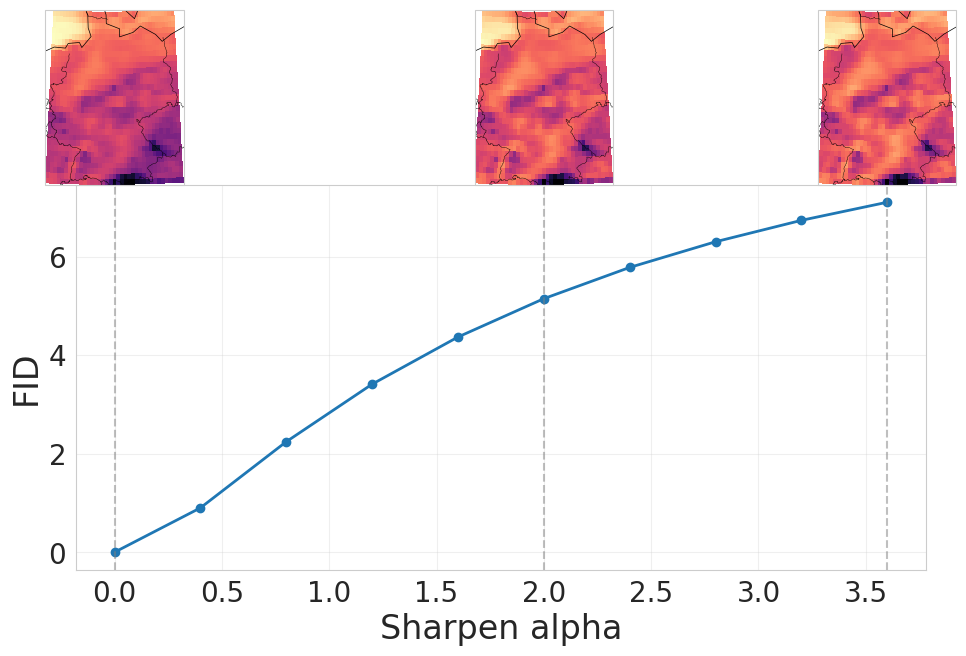

In [20]:
# Select 3 representative examples (first, middle, last)
rows_list = list(df_filter.iter_rows(named=True))
n_examples = len(rows_list)
indices = [0, n_examples // 2, n_examples - 1]
selected_rows = [rows_list[i] for i in indices]

# Get data
param_values = df_filter["param_value"].to_numpy()
fid_values = df_filter["fid"].to_numpy()

# Compute shared color limits across all examples
all_data = [np.array(row["example"][0]).T for row in selected_rows]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# Create figure
fig = plt.figure(figsize=(10, 7))

# Create main line plot axes (leave room at top for insets)
ax_line = fig.add_axes([0.1, 0.1, 0.85, 0.55])

# Line plot
ax_line.plot(param_values, fid_values, marker="o", linewidth=2, markersize=6, color="tab:blue")
ax_line.set_xlabel("Sharpen alpha", fontsize=24)
ax_line.set_ylabel("FID", fontsize=24)
ax_line.tick_params(axis="both", which="major", labelsize=20)
ax_line.grid(True, alpha=0.3)

# Get axis limits for positioning
x_min, x_max = param_values.min(), param_values.max()
x_range = x_max - x_min
ax_line.set_xlim(x_min - 0.05 * x_range, x_max + 0.05 * x_range)
x_min_ax, x_max_ax = ax_line.get_xlim()

# Add vertical lines and inset geo axes for each example
inset_width = 0.18
inset_height = 0.25
inset_bottom = 0.65  # Touch the top of the plot (0.1 + 0.55 = 0.65)

for row in selected_rows:
    x_pos = row["param_value"]
    example = row["example"]

    # Convert x data coordinate to figure fraction
    # ax_line spans [0.1, 0.95] in figure coords (width 0.85 starting at 0.1)
    x_frac_in_ax = (x_pos - x_min_ax) / (x_max_ax - x_min_ax)
    x_frac_fig = 0.1 + x_frac_in_ax * 0.85

    # Create GeoAxes using fig.add_axes with projection
    ax_inset = fig.add_axes(
        [x_frac_fig - inset_width / 2, inset_bottom, inset_width, inset_height],
        projection=ccrs.LambertConformal(central_longitude=10, central_latitude=51),
    )

    # Plot with cartopy
    ax_inset.pcolormesh(
        lon,
        lat,
        np.array(example[0]).T,
        cmap="magma",
        transform=ccrs.PlateCarree(),
        shading="auto",
        rasterized=True,
        vmin=vmin,
        vmax=vmax,
    )
    ax_inset.coastlines(resolution="110m", linewidth=0.5)
    ax_inset.add_feature(cfeature.BORDERS, linewidth=0.3)
    # ax_inset.set_title(f"σ = {row['param_value']:.1f}", fontsize=9, pad=2)

    # Add vertical line inside the plot
    ax_line.axvline(x_pos, color="gray", linestyle="--", alpha=0.5)

plt.savefig(RESULTS_DIR / "fid" / "sharpen.pdf", bbox_inches="tight")

### Gaussian Noise

In [21]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("GaussianNoise"))
p1 = df_filter.hvplot.line(
    x="param_value",
    y="fid",
    title="FID on Val Set vs Gaussian Noise Sigma",
    width=600,
    height=400,
    legend="top_left",
)

p1

:Curve   [param_value]   (fid)

In [22]:
# plot_example(df_filter, title="Example with Gaussian Noise (sigma=")

In [32]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("GaussianNoise"))

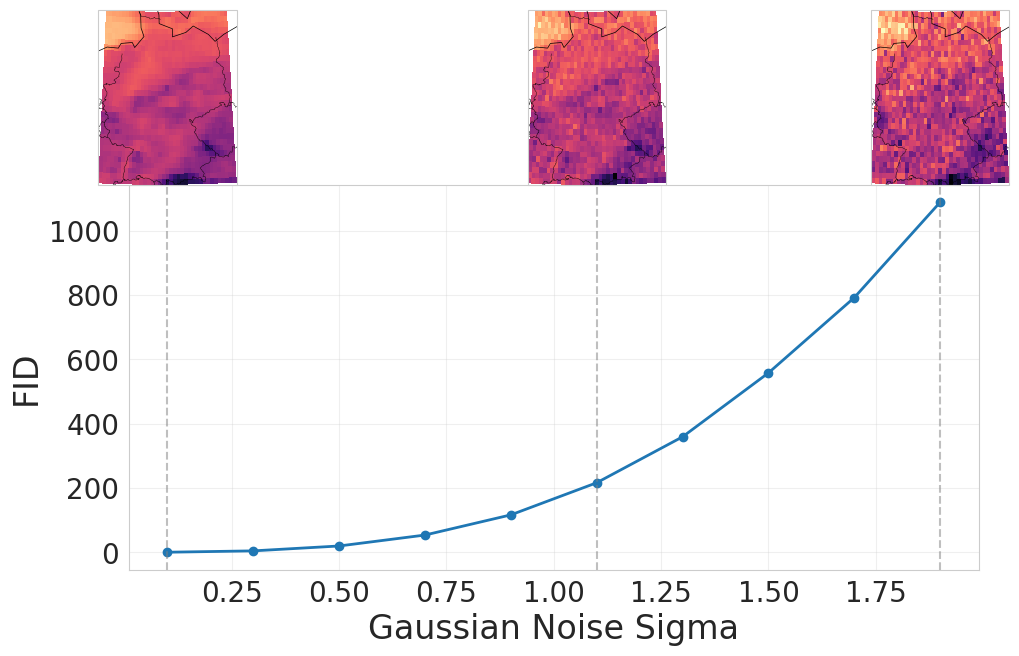

In [ ]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("GaussianNoise"))

# Select 3 representative examples (first, middle, last)
rows_list = list(df_filter.iter_rows(named=True))
n_examples = len(rows_list)
indices = [0, n_examples // 2, n_examples - 1]
selected_rows = [rows_list[i] for i in indices]

# Get data
param_values = df_filter["param_value"].to_numpy()
fid_values = df_filter["fid"].to_numpy()


# Compute shared color limits across all examples
all_data = [np.array(row["example"][0]).T for row in selected_rows]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# Create figure
fig = plt.figure(figsize=(10, 7))

# Create main line plot axes (leave room at top for insets)
ax_line = fig.add_axes([0.1, 0.1, 0.85, 0.55])

# Line plot
ax_line.plot(param_values, fid_values, marker="o", linewidth=2, markersize=6, color="tab:blue")
ax_line.set_xlabel("Gaussian Noise Sigma", fontsize=24)
ax_line.set_ylabel("FID", fontsize=24)
ax_line.tick_params(axis="both", which="major", labelsize=20)
ax_line.grid(True, alpha=0.3)

# Get axis limits for positioning
x_min, x_max = param_values.min(), param_values.max()
x_range = x_max - x_min
ax_line.set_xlim(x_min - 0.05 * x_range, x_max + 0.05 * x_range)
x_min_ax, x_max_ax = ax_line.get_xlim()

# Add vertical lines and inset geo axes for each example
inset_width = 0.18
inset_height = 0.25
inset_bottom = 0.65  # Touch the top of the plot (0.1 + 0.55 = 0.65)

for row in selected_rows:
    x_pos = row["param_value"]
    example = row["example"]

    # Convert x data coordinate to figure fraction
    # ax_line spans [0.1, 0.95] in figure coords (width 0.85 starting at 0.1)
    x_frac_in_ax = (x_pos - x_min_ax) / (x_max_ax - x_min_ax)
    x_frac_fig = 0.1 + x_frac_in_ax * 0.85

    # Create GeoAxes using fig.add_axes with projection
    ax_inset = fig.add_axes(
        [x_frac_fig - inset_width / 2, inset_bottom, inset_width, inset_height],
        projection=ccrs.LambertConformal(central_longitude=10, central_latitude=51),
    )

    # Plot with cartopy
    ax_inset.pcolormesh(
        lon,
        lat,
        np.array(example[0]).T,
        cmap="magma",
        transform=ccrs.PlateCarree(),
        shading="auto",
        rasterized=True,
        vmin=vmin,
        vmax=vmax,
    )
    ax_inset.coastlines(resolution="110m", linewidth=0.5)
    ax_inset.add_feature(cfeature.BORDERS, linewidth=0.3)
    # ax_inset.set_title(f"σ = {row['param_value']:.1f}", fontsize=9, pad=2)

    # Add vertical line inside the plot
    ax_line.axvline(x_pos, color="gray", linestyle="--", alpha=0.5)

plt.savefig(RESULTS_DIR / "fid" / "gaussian_noise.pdf", bbox_inches="tight")

### Gaussian Blur

In [24]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("GaussianBlur"))
p2 = df_filter.hvplot.line(
    x="param_value",
    y="fid",
    title="FID on Val Set vs Gaussian Blur Kernel Size",
    width=600,
    height=400,
    legend="top_left",
)
p2

:Curve   [param_value]   (fid)

In [25]:
# plot_example(df_filter, title="Example with Gaussian Noise (kernel_size=")

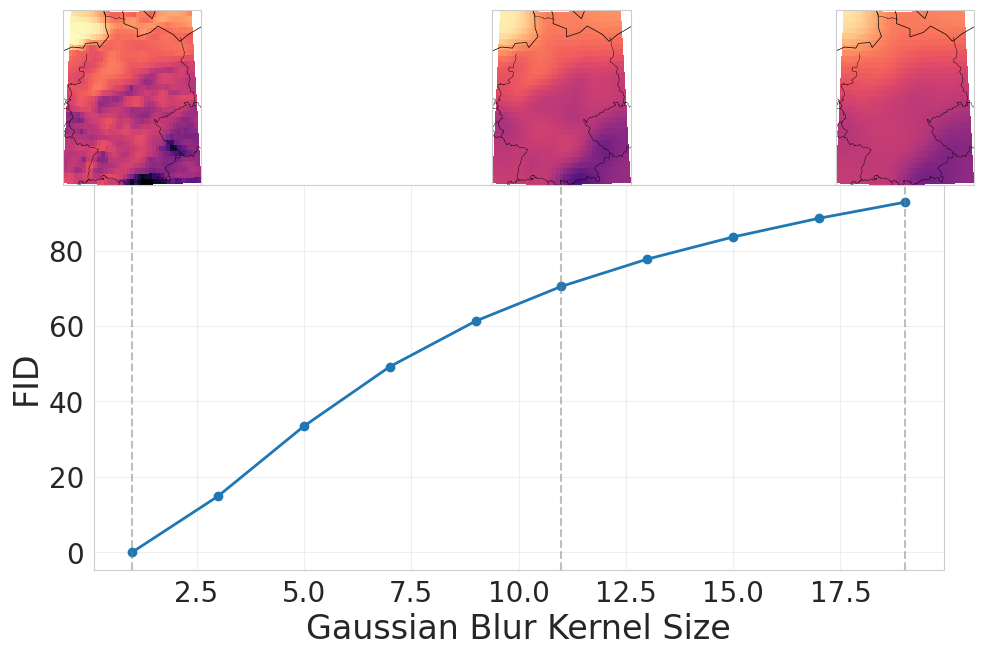

In [26]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("GaussianBlur"))

# Select 3 representative examples (first, middle, last)
rows_list = list(df_filter.iter_rows(named=True))
n_examples = len(rows_list)
indices = [0, n_examples // 2, n_examples - 1]
selected_rows = [rows_list[i] for i in indices]

# Get data
param_values = df_filter["param_value"].to_numpy()
fid_values = df_filter["fid"].to_numpy()

# Compute shared color limits across all examples
all_data = [np.array(row["example"][0]).T for row in selected_rows]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# Create figure
fig = plt.figure(figsize=(10, 7))

# Create main line plot axes (leave room at top for insets)
ax_line = fig.add_axes([0.1, 0.1, 0.85, 0.55])

# Line plot
ax_line.plot(param_values, fid_values, marker="o", linewidth=2, markersize=6, color="tab:blue")
ax_line.set_xlabel("Gaussian Blur Kernel Size", fontsize=24)
ax_line.set_ylabel("FID", fontsize=24)
ax_line.tick_params(axis="both", which="major", labelsize=20)
ax_line.grid(True, alpha=0.3)

# Get axis limits for positioning
x_min, x_max = param_values.min(), param_values.max()
x_range = x_max - x_min
ax_line.set_xlim(x_min - 0.05 * x_range, x_max + 0.05 * x_range)
x_min_ax, x_max_ax = ax_line.get_xlim()

# Add vertical lines and inset geo axes for each example
inset_width = 0.18
inset_height = 0.25
inset_bottom = 0.65  # Touch the top of the plot (0.1 + 0.55 = 0.65)

for row in selected_rows:
    x_pos = row["param_value"]
    example = row["example"]

    # Convert x data coordinate to figure fraction
    x_frac_in_ax = (x_pos - x_min_ax) / (x_max_ax - x_min_ax)
    x_frac_fig = 0.1 + x_frac_in_ax * 0.85

    # Create GeoAxes using fig.add_axes with projection
    ax_inset = fig.add_axes(
        [x_frac_fig - inset_width / 2, inset_bottom, inset_width, inset_height],
        projection=ccrs.LambertConformal(central_longitude=10, central_latitude=51),
    )

    # Plot with cartopy
    ax_inset.pcolormesh(
        lon,
        lat,
        np.array(example[0]).T,
        cmap="magma",
        transform=ccrs.PlateCarree(),
        shading="auto",
        rasterized=True,
        vmin=vmin,
        vmax=vmax,
    )
    ax_inset.coastlines(resolution="110m", linewidth=0.5)
    ax_inset.add_feature(cfeature.BORDERS, linewidth=0.3)

    # Add vertical line inside the plot
    ax_line.axvline(x_pos, color="gray", linestyle="--", alpha=0.5)

plt.savefig(RESULTS_DIR / "fid" / "gaussian_blur.pdf", bbox_inches="tight")

### Random Erasing

In [27]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("RandomErasing"))
p3 = df_filter.hvplot.line(
    x="param_value",
    y="fid",
    title="FID on Val Set vs Random Erasing Scale",
    width=600,
    height=400,
    legend="top_left",
)
p3

:Curve   [param_value]   (fid)

In [28]:
# plot_example(df_filter, title="Example with Random Erasing (scale=")

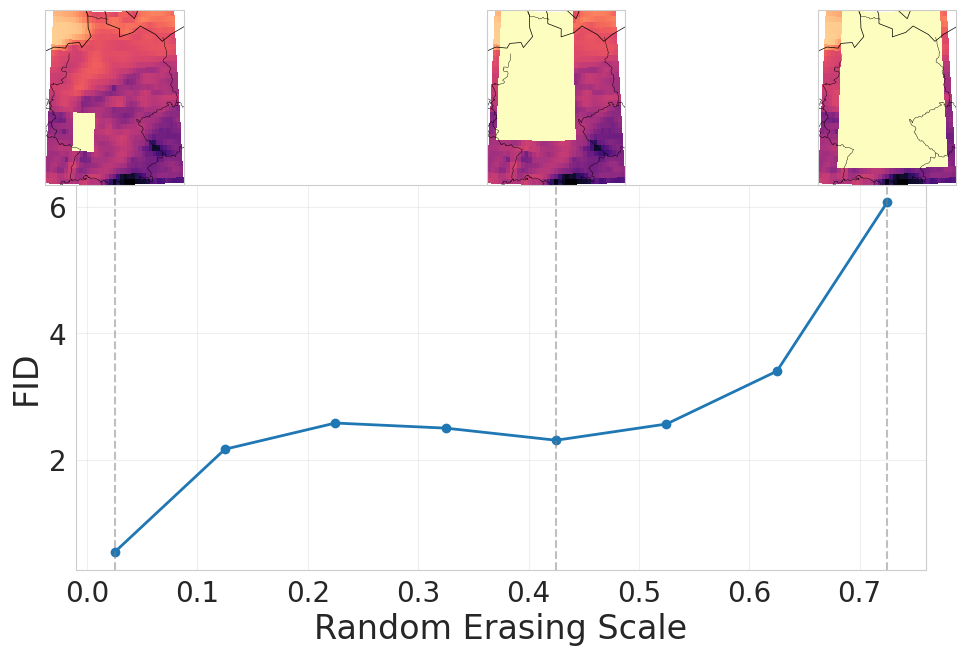

In [29]:
df_filter = fid_df_noise.filter(pl.col("defect").str.contains("RandomErasing"))

# Select 3 representative examples (first, middle, last)
rows_list = list(df_filter.iter_rows(named=True))
n_examples = len(rows_list)
indices = [0, n_examples // 2, n_examples - 1]
selected_rows = [rows_list[i] for i in indices]

# Get data
param_values = df_filter["param_value"].to_numpy()
fid_values = df_filter["fid"].to_numpy()

# Compute shared color limits across all examples
all_data = [np.array(row["example"][0]).T for row in selected_rows]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

# Create figure
fig = plt.figure(figsize=(10, 7))

# Create main line plot axes (leave room at top for insets)
ax_line = fig.add_axes([0.1, 0.1, 0.85, 0.55])

# Line plot
ax_line.plot(param_values, fid_values, marker="o", linewidth=2, markersize=6, color="tab:blue")
ax_line.set_xlabel("Random Erasing Scale", fontsize=24)
ax_line.set_ylabel("FID", fontsize=24)
ax_line.tick_params(axis="both", which="major", labelsize=20)
ax_line.grid(True, alpha=0.3)

# Get axis limits for positioning
x_min, x_max = param_values.min(), param_values.max()
x_range = x_max - x_min
ax_line.set_xlim(x_min - 0.05 * x_range, x_max + 0.05 * x_range)
x_min_ax, x_max_ax = ax_line.get_xlim()

# Add vertical lines and inset geo axes for each example
inset_width = 0.18
inset_height = 0.25
inset_bottom = 0.65  # Touch the top of the plot (0.1 + 0.55 = 0.65)

for row in selected_rows:
    x_pos = row["param_value"]
    example = row["example"]

    # Convert x data coordinate to figure fraction
    x_frac_in_ax = (x_pos - x_min_ax) / (x_max_ax - x_min_ax)
    x_frac_fig = 0.1 + x_frac_in_ax * 0.85

    # Create GeoAxes using fig.add_axes with projection
    ax_inset = fig.add_axes(
        [x_frac_fig - inset_width / 2, inset_bottom, inset_width, inset_height],
        projection=ccrs.LambertConformal(central_longitude=10, central_latitude=51),
    )

    # Plot with cartopy
    ax_inset.pcolormesh(
        lon,
        lat,
        np.array(example[0]).T,
        cmap="magma",
        transform=ccrs.PlateCarree(),
        shading="auto",
        rasterized=True,
        vmin=vmin,
        vmax=vmax,
    )
    ax_inset.coastlines(resolution="110m", linewidth=0.5)
    ax_inset.add_feature(cfeature.BORDERS, linewidth=0.3)

    # Add vertical line inside the plot
    ax_line.axvline(x_pos, color="gray", linestyle="--", alpha=0.5)

plt.savefig(RESULTS_DIR / "fid" / "random_erasing.pdf", bbox_inches="tight")